In [1]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_model_optimization as tfmot
print(tfmot.__version__)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

I0000 00:00:1783887529.157450  773049 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783887529.161011  773049 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783887529.496388  773049 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783887531.006693  773049 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

0.8.1


In [142]:
IMG_SIZE = 160
FEATURE_DIM = 64
PROJECTION_DIM = 64
BATCH_SIZE = 32
EPOCHS = 40   # or whatever epoch count you're planning
TEMPERATURE = 0.1
NUM_DOMAINS = 2

SOURCE_DIR= '/media/iot-lab/Projects/Nazifa/Unlearning/feature_unlearning/Bangladeshi_Crops_Disease_Dataset/train'
TARGET_DIR= '/media/iot-lab/Projects/Nazifa/Unlearning/feature_unlearning/PlantVillage-Dataset/raw/segmented'


SOURCE_CLASSES= [
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___Early_blight",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Rice_brown_spot"]

TARGET_CLASSES = [
    "Tomato___Bacterial_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___Early_blight",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Tomato___Septoria_leaf_spot",
    "Strawberry___Leaf_scorch"
]  

In [136]:
# ===============================================================
# AUGMENTATIONS (ENHANCED)
# ===============================================================
def strong_aug(x):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_flip_up_down(x)
    x = tf.image.random_brightness(x, 0.8)
    x = tf.image.random_contrast(x, 0.5, 1.5)
    x = tf.image.random_saturation(x, 0.5, 1.5)
    # keep hue removed — that was correct
    return tf.clip_by_value(x, 0, 1)

# Simplified create_views to apply strong augmentation to both views for contrastive learning
def create_views(img):
    img = tf.cast(img, tf.float32) / 255.0
    return strong_aug(img), strong_aug(img)


In [144]:
# ===============================================================
# GENERATOR (compact, with source + target verification)
# ===============================================================
def verify_classes(base_dir, classes, name):
    print(f"--- {name} ({base_dir}) ---")
    print("On disk:", os.listdir(base_dir))
    bad = []
    for c in classes:
        p = os.path.join(base_dir, c)
        n = len(os.listdir(p)) if os.path.isdir(p) else -1
        print(f"  {'OK ' if n > 0 else 'BAD'} {c:60s} -> {n if n >= 0 else 'MISSING'}")
        if n <= 0:
            bad.append(c)
    if bad:
        raise ValueError(f"{name}: unresolved classes -> {bad}")


def combined_generator(batch_size=BATCH_SIZE):
    verify_classes(SOURCE_DIR, SOURCE_CLASSES, "SOURCE")
    verify_classes(TARGET_DIR, TARGET_CLASSES, "TARGET")

    datagen = ImageDataGenerator()
    s_gen = datagen.flow_from_directory(
        SOURCE_DIR, classes=SOURCE_CLASSES, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=batch_size // 2, shuffle=True, class_mode=None
    )
    t_gen = datagen.flow_from_directory(
        TARGET_DIR, classes=TARGET_CLASSES, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=batch_size // 2, shuffle=True, class_mode=None
    )

    assert s_gen.num_classes == len(SOURCE_CLASSES), s_gen.class_indices
    assert t_gen.num_classes == len(TARGET_CLASSES), t_gen.class_indices
    print("SOURCE class_indices:", s_gen.class_indices, "| samples:", s_gen.samples)
    print("TARGET class_indices:", t_gen.class_indices, "| samples:", t_gen.samples)

    while True:
        xs, xt = next(s_gen), next(t_gen)
        X = np.concatenate([xs, xt], axis=0)
        domain = tf.concat([
            tf.zeros(xs.shape[0], dtype=tf.int32),
            tf.ones(xt.shape[0], dtype=tf.int32)
        ], axis=0)
        v1, v2 = zip(*(create_views(img) for img in X))
        yield (tf.stack(v1), tf.stack(v2)), domain



In [143]:
# ===============================================================
# ENCODER (SIMPLIFIED & STRONGER)
# TinyML config: MobileNetV2, alpha=0.75, reduced input resolution
# ===============================================================
def build_encoder():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
        alpha=0.75
    )
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(FEATURE_DIM, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(FEATURE_DIM)(x)
    return models.Model(base.input, x)

In [139]:
#================================================================
# UNLEARNING
# ===============================================================
class AdaptiveMMDUnlearning(tf.keras.layers.Layer):
    def __init__(self, dim, num_domains, k=2, sigma=1.0, temperature=0.5):
        super().__init__()
        self.dim = dim
        self.num_domains = num_domains
        self.k = k
        self.sigma = sigma
        self.temperature = temperature

    def build(self, _):
        self.domain_basis = self.add_weight(
            shape=(self.num_domains, self.k, self.dim),
            initializer="orthogonal",
            trainable=True,
            name="domain_basis"
        )
        self.lambda_unlearn = self.add_weight(
            shape=(1,),
            initializer=tf.keras.initializers.Constant(0.3),
            trainable=True,
            constraint=tf.keras.constraints.MinMaxNorm(min_value=0.1,max_value=0.6),
            name="lambda_unlearn"
        )
        self.log_sigma = self.add_weight(
            shape=(1,),
            initializer=tf.keras.initializers.Constant(0.0),
            trainable=True,
            name="log_sigma"
        )

    def _mmd_gate(self, f, d):
        sigma = tf.exp(self.log_sigma)
        f0 = tf.boolean_mask(f, tf.equal(d, 0))
        f1 = tf.boolean_mask(f, tf.equal(d, 1))

        batch_safe = tf.logical_and(
            tf.greater(tf.shape(f0)[0], 1),
            tf.greater(tf.shape(f1)[0], 1)
        )

        def compute_gate():
            mu0 = tf.reduce_mean(f0, axis=0)
            mu1 = tf.reduce_mean(f1, axis=0)
            diff_sq = tf.square(mu0 - mu1)
            pooled_var = (tf.math.reduce_variance(f0, axis=0) +
                          tf.math.reduce_variance(f1, axis=0)) / 2.0 + 1e-8
            discrepancy = diff_sq / pooled_var
            return tf.exp(-discrepancy / (2.0 * tf.square(sigma)))

        gate = tf.cond(
            batch_safe,
            compute_gate,
            lambda: tf.ones(self.dim, dtype=f.dtype)
        )
        return tf.expand_dims(gate, axis=0)

    def _ocm_projection(self, f_norm, d):
        B = tf.math.l2_normalize(tf.gather(self.domain_basis, d), axis=2)
        f_exp = tf.expand_dims(f_norm, axis=1)
        proj_coeff = tf.clip_by_value(
            tf.reduce_sum(f_exp * B, axis=2, keepdims=True), -1.0, 1.0
        )
        return tf.reduce_sum(proj_coeff * B, axis=1)

    def call(self, f, d, training=None):
        f_norm = tf.math.l2_normalize(f, axis=1)
        gate = self._mmd_gate(f_norm, d)
        proj = self._ocm_projection(f_norm, d)
        f_clean = f_norm - self.lambda_unlearn * (proj * (1.0 - gate))
        return tf.math.l2_normalize(f_clean, axis=1)

    def gate_entropy_loss(self, f, d):
        gate = self._mmd_gate(f, d)
        entropy = -gate * tf.math.log(gate + 1e-8) \
                  - (1 - gate) * tf.math.log(1 - gate + 1e-8)
        return tf.reduce_mean(entropy)
    

In [145]:
# ===============================================================
# LOSSES
# ===============================================================
def nt_xent(z1, z2, temp=0.1):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)

    z = tf.concat([z1, z2], axis=0)
    sim = tf.matmul(z, z, transpose_b=True) / temp

    mask = tf.eye(tf.shape(z)[0])
    sim -= mask * 1e9

    bs = tf.shape(z1)[0]
    labels = tf.concat([tf.range(bs, 2*bs), tf.range(bs)], axis=0)

    loss = tf.keras.losses.sparse_categorical_crossentropy(labels, sim, from_logits=True)
    return tf.reduce_mean(loss)


In [146]:
# ===============================================================
# MODEL (UPDATED FOR PSEUDO-LABELING)
# Removed GRL and domain_head for pseudo-labeling approach
# ===============================================================
class FullModel(tf.keras.Model):
    def __init__(self, enc):
        super().__init__()
        self.enc = enc
       
        self.proj = models.Sequential([
            layers.Dense(PROJECTION_DIM, activation='relu'),
            layers.Dense(PROJECTION_DIM)
        ])
        self.un = AdaptiveMMDUnlearning(
            dim=FEATURE_DIM,
            num_domains=NUM_DOMAINS,
            k=1
        )

    def train_step(self, data):
        (v1, v2), d = data

        with tf.GradientTape() as tape:
            h1 = self.enc(v1, training=True)
            h2 = self.enc(v2, training=True)

            h1_unlearned = self.un(h1, d, training=True)
            h2_unlearned = self.un(h2, d, training=True)

            z1 = self.proj(h1_unlearned)
            z2 = self.proj(h2_unlearned)

            loss_c = nt_xent(z1, z2)

            loss_gate = (
                self.un.gate_entropy_loss(h1_unlearned, d) +
                self.un.gate_entropy_loss(h2_unlearned, d)
            ) / 2.0

            loss = 1.0 * loss_c + 0.001 * loss_gate

        trainable_vars = (self.enc.trainable_variables +
                          self.un.trainable_variables +
                          self.proj.trainable_variables)

        grads = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(grads, trainable_vars))

        gate_vals = self.un._mmd_gate(h1_unlearned, d)

        return {
            "total": loss,
            "contrastive": loss_c,
            "gate_entropy": loss_gate,
            "lambda_unlearn": self.un.lambda_unlearn[0],
            "sigma": tf.exp(self.un.log_sigma)[0],
            "gate_mean": tf.reduce_mean(gate_vals),
            "gate_std": tf.math.reduce_std(gate_vals)
        }

In [147]:
# ===============================================================
# TRAIN
# ===============================================================
enc = build_encoder()

# 🔥 IMPORTANT: UNFREEZE ALL ENCODER LAYERS for full fine-tuning during DA
for layer in enc.layers:
    layer.trainable = True

model = FullModel(enc)
model.compile(optimizer=tf.keras.optimizers.Adam(5e-5)) # Slightly reduced learning rate

gen = combined_generator()

print("🚀 Training with stronger settings and pseudo-labeling for improved accuracy...")
model.fit(gen, steps_per_epoch=200, epochs=EPOCHS, verbose=1)


🚀 Training with stronger settings and pseudo-labeling for improved accuracy...
--- SOURCE (/media/iot-lab/Projects/Nazifa/Unlearning/feature_unlearning/Bangladeshi_Crops_Disease_Dataset/train) ---
On disk: ['Rice_brown_spot', 'Tomato___Late_blight', 'Corn_(maize)___Common_rust_', 'Tomato___healthy', 'Wheat Brown rust', 'Potato___Early_blight', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Rice_bacterial_leaf_blight', 'Corn_(maize)___Northern_Leaf_Blight', 'Wheat Healthy', 'Rice_healthy', 'Potato___healthy', 'Tomato___Early_blight', 'Rice_leaf_blast', 'Potato___Late_blight', 'Corn_(maize)___healthy', 'Wheat Yellow rust', 'Wheat Loose Smut', 'Tomato___Bacterial_spot']
  OK  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot           -> 360
  OK  Corn_(maize)___Northern_Leaf_Blight                          -> 360
  OK  Potato___Early_blight                                        -> 360
  OK  Tomato___Bacterial_spot                                      -> 360
  OK  Tomato___Early

In [148]:

#===============================================================
# SAVE ENCODER
# ===============================================================
model.enc.save("MV2_Encoder_alpha75_160image_BtoP.h5")

In [84]:
(v1, v2), d = next(gen)
h1 = model.enc(v1, training=False)
h1_norm = tf.math.l2_normalize(h1, axis=1)

sim_matrix = tf.matmul(h1_norm, h1_norm, transpose_b=True)
print("Mean pairwise similarity:", tf.reduce_mean(sim_matrix).numpy())
print("Std of embeddings across batch:", tf.math.reduce_std(h1, axis=0).numpy().mean())

Mean pairwise similarity: 0.021849431
Std of embeddings across batch: 1.1904771


In [98]:

print(type(enc))
print(hasattr(enc, '_is_graph_network'), getattr(enc, '_is_graph_network', None))

<class 'keras.src.models.functional.Functional'>
False None


In [ ]:
enc = tf.keras.models.load_model("MV2_Encoder_alpha75_160image_BtoP.h5", compile=False)

model = FullModel(enc)   # rewrap in your FullModel/unlearning setup
model.compile(optimizer=tf.keras.optimizers.Adam(5e-5))

# continue for 20 more epochs to reach 40 total
model.fit(gen, steps_per_epoch=200, epochs=20, verbose=1)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - contrastive: 0.6906 - gate_entropy: 0.3207 - gate_mean: 0.7546 - gate_std: 0.2829 - lambda_unlearn: 0.3019 - sigma: 0.9992 - total: 0.6909
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - contrastive: 0.4187 - gate_entropy: 0.3251 - gate_mean: 0.7742 - gate_std: 0.2633 - lambda_unlearn: 0.3030 - sigma: 0.9989 - total: 0.4191
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - contrastive: 0.3537 - gate_entropy: 0.3169 - gate_mean: 0.7872 - gate_std: 0.2682 - lambda_unlearn: 0.3032 - sigma: 0.9997 - total: 0.3540
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - contrastive: 0.2433 - gate_entropy: 0.3207 - gate_mean: 0.7824 - gate_std: 0.2623 - lambda_unlearn: 0.3039 - sigma: 0.9997 - total: 0.2436
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - contrastive: 1.0878 - gate_entropy: 0.3284 - gate_mean: 0.7901 - gate_std: 0.2532 - lambda_unlearn: 0.3042 - sigma: 1.0010 - total: 1.0881
Epoch 6/20
200/200 ━━━━━━━━━━━

In [67]:

#===============================================================
# SAVE ENCODER
# ===============================================================
model.enc.save("MV2_Encoder_alpha75_160image_BtoP.h5")

In [133]:
print(type(enc))
print(hasattr(enc, '_is_graph_network'), getattr(enc, '_is_graph_network', None))

<class 'keras.src.models.functional.Functional'>
False None


In [151]:
# ===============================================================
# LINEAR EVALUATION
# ===============================================================

enc.trainable = False # Freeze encoder for linear evaluation

clf = tf.keras.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    enc,
    layers.Dense(len(TARGET_CLASSES), activation='softmax')
])

clf.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train = datagen.flow_from_directory(
    TARGET_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    subset='training', class_mode='categorical',
    classes=TARGET_CLASSES # Explicitly set classes for the generator
)

val = datagen.flow_from_directory(
    TARGET_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    subset='validation', class_mode='categorical',
    classes=TARGET_CLASSES # Explicitly set classes for the generator
)

history = clf.fit(train, validation_data=val, epochs=20) # Keeping 40 epochs for linear eval

loss, acc = clf.evaluate(val)
print(f"\n🎯 Final Accuracy with stronger settings: {acc*100:.2f}%")

Found 6006 images belonging to 6 classes.
Found 1499 images belonging to 6 classes.
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.6232 - loss: 1.1435 - val_accuracy: 0.8346 - val_loss: 0.5576
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.8573 - loss: 0.4576 - val_accuracy: 0.8726 - val_loss: 0.3894
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 0.8783 - loss: 0.3619 - val_accuracy: 0.8839 - val_loss: 0.3370
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.8883 - loss: 0.3230 - val_accuracy: 0.8953 - val_loss: 0.3079
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - accuracy: 0.8939 - loss: 0.3008 - val_accuracy: 0.9006 - val_loss: 0.2928
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.8963 - loss: 0.2857 - val_accuracy: 0.8979 - val_loss: 0.2790
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.9006 - loss: 0.2745 - val_accuracy: 0.8999 - val_loss: 0.2694

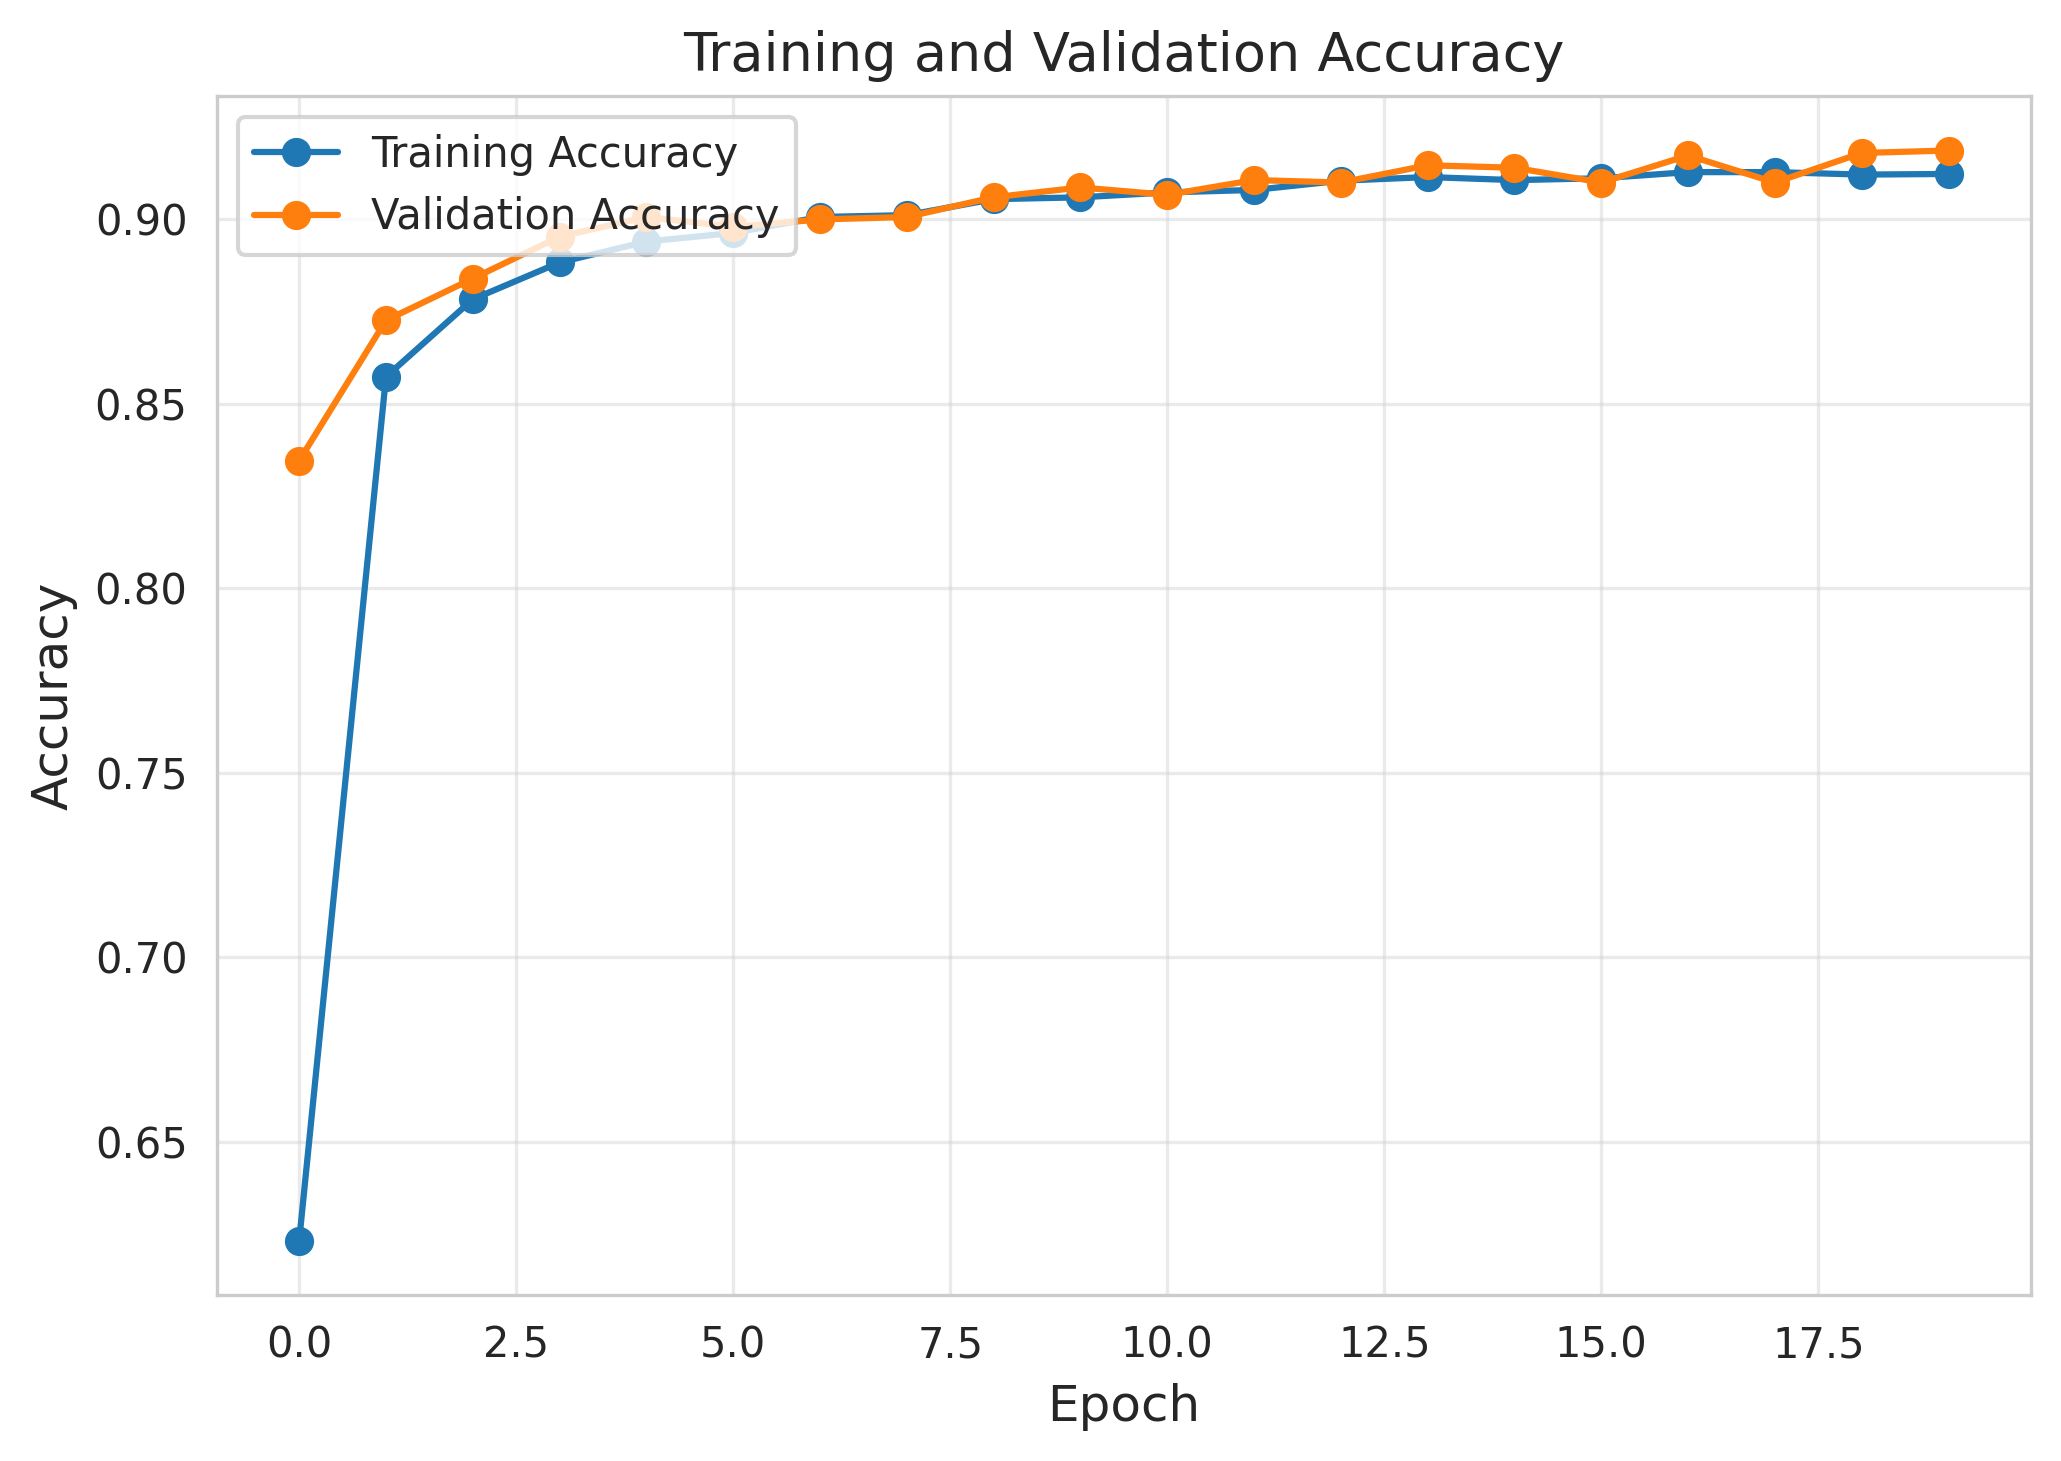

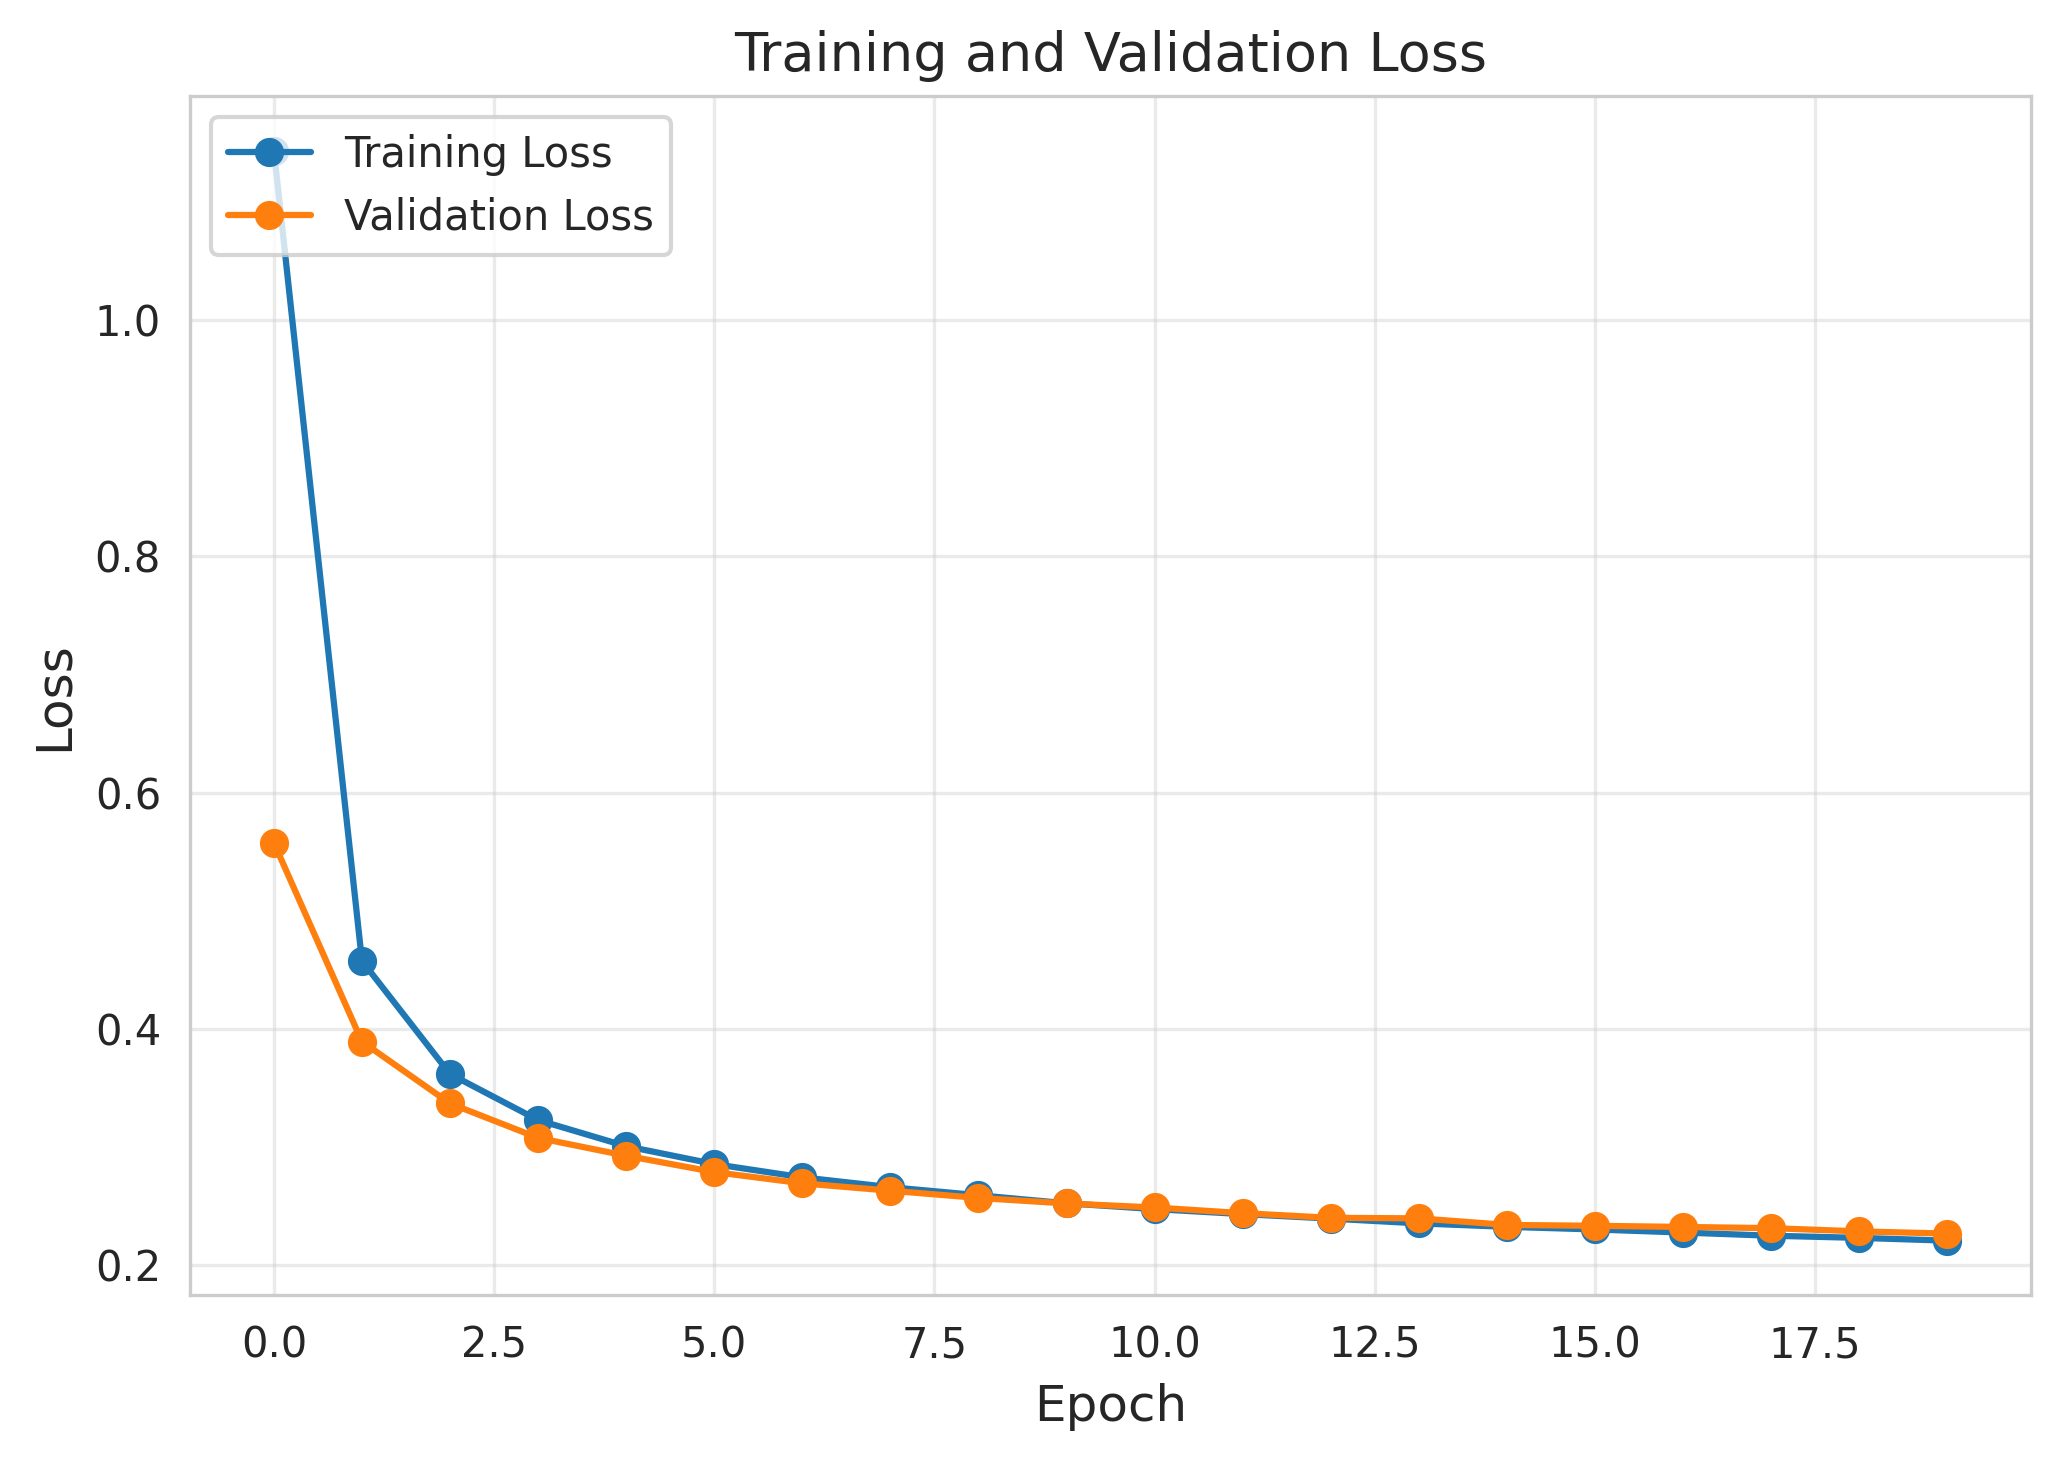

In [154]:

# ===============================================================
# TRAINING CURVE
# ===============================================================
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "paper_figuresBtoPV2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def plot_training_curves_classic(history_dict, save_name_prefix="training_curve"):
    plt.figure(figsize=(7, 5))
    plt.plot(history_dict['accuracy'], marker='o', label='Training Accuracy')
    plt.plot(history_dict['val_accuracy'], marker='o', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name_prefix}_accuracy.png", bbox_inches='tight', dpi=150)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_dict['loss'], marker='o', label='Training Loss')
    plt.plot(history_dict['val_loss'], marker='o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name_prefix}_loss.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_training_curves_classic(history.history)

In [66]:
loss, acc = clf.evaluate(val)
print(f"\n🎯 Final Accuracy with stronger settings: {acc*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9159 - loss: 0.2145

🎯 Final Accuracy with stronger settings: 91.59%


47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 528ms/step


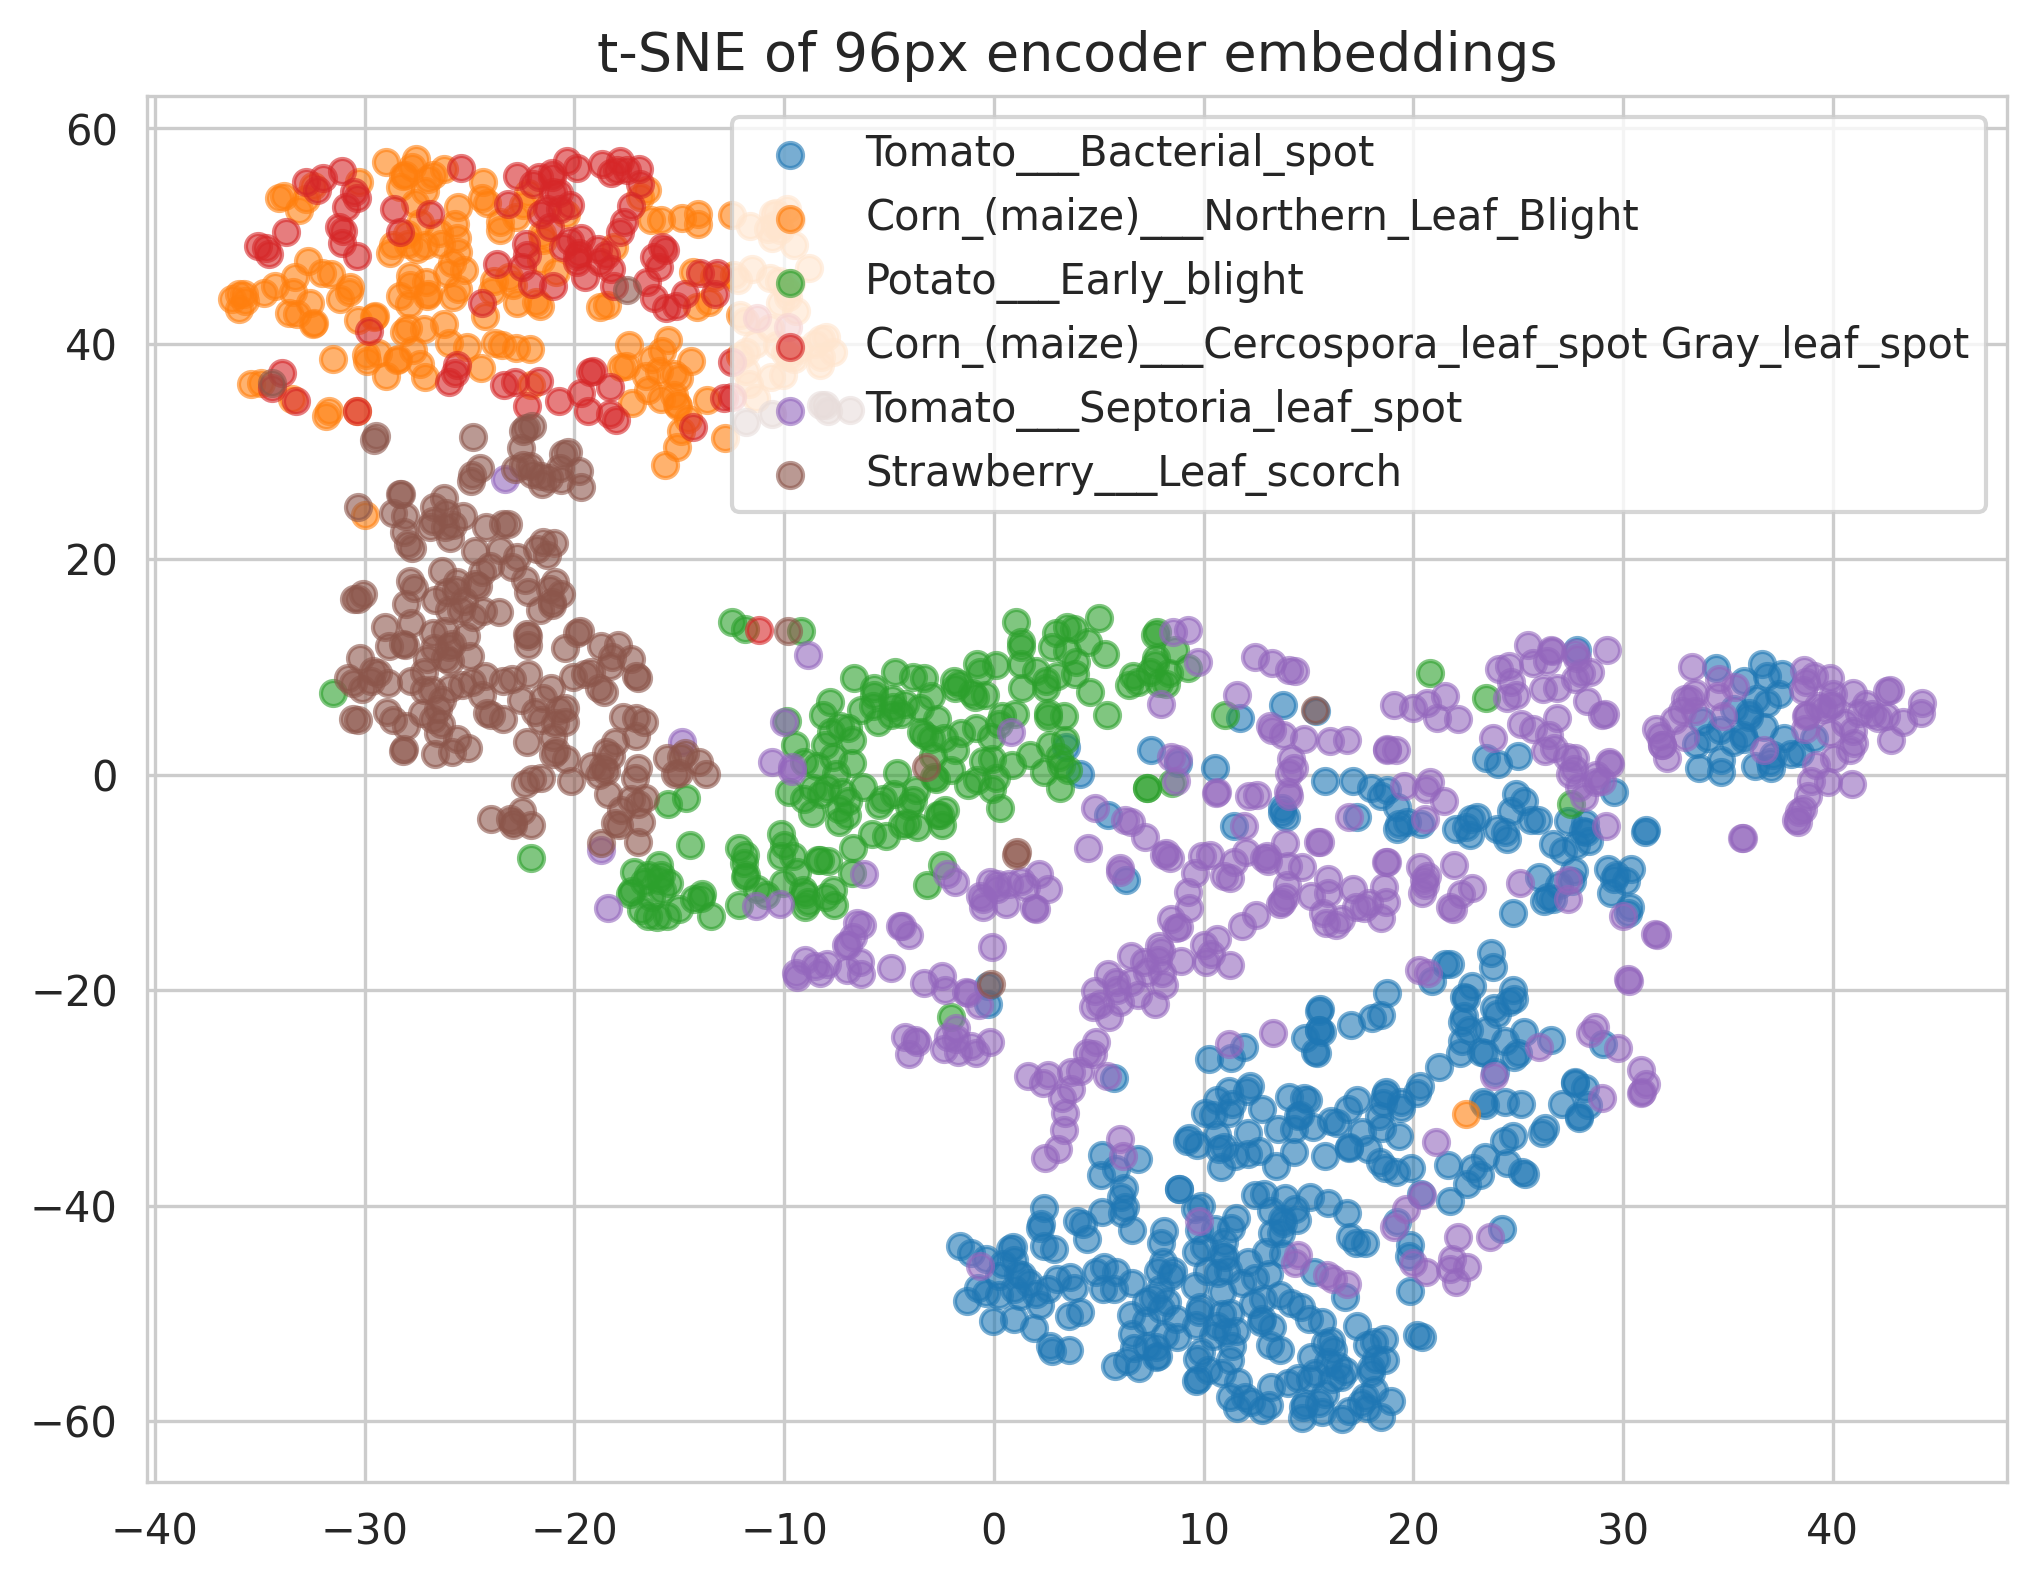

In [152]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Pull all batches from the val generator into arrays
X_val_list, y_val_list = [], []
val.reset()   # make sure we start from the beginning
steps = len(val)   # number of batches in one full pass
for i in range(steps):
    xb, yb = next(val)
    X_val_list.append(xb)
    y_val_list.append(yb)

X_val = np.concatenate(X_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0)

embeddings = model.enc.predict(X_val, batch_size=32)
labels = np.argmax(y_val, axis=1)

tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
for c in range(len(TARGET_CLASSES)):
    mask = labels == c
    plt.scatter(emb_2d[mask,0], emb_2d[mask,1], label=TARGET_CLASSES[c], alpha=0.6)
plt.legend()
plt.title("t-SNE of 96px encoder embeddings")
plt.savefig("tsne_96px.png", dpi=150)
plt.show()

In [155]:
# ===============================================================
# FP32 RESULTS
# ===============================================================
clf.save("full_da_model_alpha75_image160_FP32_BtoP.h5")

fp32_size = os.path.getsize(
    "full_da_model_alpha75_image160_FP32_BtoP.h5"
) / (1024 * 1024)

print("\n===== FP32 =====")
print(f"Accuracy : {acc*100:.2f}%")
print(f"Size     : {fp32_size:.2f} MB")


===== FP32 =====
Accuracy : 91.86%
Size     : 5.96 MB


In [156]:
# ===============================================================
# INT8 PTQ
# ===============================================================
def representative_data_gen():

    count = 0

    for images, _ in train:

        for img in images:

            yield [np.expand_dims(
                img.astype(np.float32),
                axis=0
            )]

            count += 1

            if count >= 300:
                return


converter = tf.lite.TFLiteConverter.from_keras_model(clf)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("full_da_model75_image160_BtoP_int8_ptq.tflite", "wb") as f:
    f.write(tflite_model)

ptq_size = os.path.getsize(
    "full_da_model75_image160_BtoP_int8_ptq.tflite"
) / (1024 * 1024)

print("\n===== INT8 PTQ =====")
print(f"Size : {ptq_size:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpmfmj416g/assets


INFO:tensorflow:Assets written to: /tmp/tmpmfmj416g/assets


Saved artifact at '/tmp/tmpmfmj416g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_4803')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  124072707189824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707122880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707114784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707121120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707117600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707193344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707117776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707126400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707113376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124072707117248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124064539

/home/iot-lab/miniconda3/envs/leafenv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784040944.579554  773049 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784040944.579996  773049 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784040944.580872  773049 reader.cc:83] Reading SavedModel from: /tmp/tmpmfmj416g
I0000 00:00:1784040944.601186  773049 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784040944.601270  773049 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpmfmj416g
I0000 00:00:1784040945.155490  773049 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784040949.499792  773049 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpmfmj416g
I0000 00:00:1784040950.496184  773049 loader.cc:471] SavedModel loa


===== INT8 PTQ =====
Size : 1.77 MB


In [117]:
import tensorflow_model_optimization as tfmot
print(tfmot.__version__)

0.8.1


In [157]:
# ===============================================================
# TFLITE ACCURACY EVALUATION
# ===============================================================
import numpy as np
import tensorflow as tf

def evaluate_tflite(model_path, val_gen):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    correct = 0
    total = 0

    val_gen.reset()

    for _ in range(len(val_gen)):
        x_batch, y_batch = next(val_gen)

        for i in range(len(x_batch)):
            x = x_batch[i:i+1]

            # INT8 quantization parameters
            input_scale, input_zero_point = \
                input_details[0]['quantization']

            x_int8 = (x / input_scale + input_zero_point)
            x_int8 = np.clip(x_int8, -128, 127).astype(np.int8)

            interpreter.set_tensor(
                input_details[0]['index'],
                x_int8
            )

            interpreter.invoke()

            output = interpreter.get_tensor(
                output_details[0]['index']
            )

            # dequantize output
            output_scale, output_zero_point = \
                output_details[0]['quantization']

            output = (
                output.astype(np.float32) - output_zero_point
            ) * output_scale

            pred = np.argmax(output)
            true = np.argmax(y_batch[i])

            correct += int(pred == true)
            total += 1

    acc = correct / total
    print(f"TFLite Accuracy: {acc*100:.2f}%")

    return acc

In [158]:
ptq_acc = evaluate_tflite('full_da_model75_image160_BtoP_int8_ptq.tflite', val)

/home/iot-lab/miniconda3/envs/leafenv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite Accuracy: 90.53%


In [74]:
print("\n==============================")
print(f"FP32 Accuracy     : {acc*100:.2f}%")
print(f"FP32 Size         : {fp32_size:.2f} MB")
print("------------------------------")
# print(f"QAT Accuracy      : {qat_acc*100:.2f}%")
# print(f"QAT Size          : {qat_size:.2f} MB")
print("------------------------------")
print(f"PTQ Accuracy     : {ptq_acc*100:.2f}%")
print(f"INT8 PTQ Size     : {ptq_size:.2f} MB")
# print(f"QAT+INT8 Size     : {qat_int8_size:.2f} MB")
print("==============================")


FP32 Accuracy     : 91.46%
FP32 Size         : 5.96 MB
------------------------------
------------------------------
PTQ Accuracy     : 88.93%
INT8 PTQ Size     : 1.77 MB


In [165]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar

OUTPUT_DIR = "paper_figuresBtoPTesting"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# GLOBAL STYLE
# ==========================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_style("whitegrid")

OUTPUT_DIR = "paper_figuresBtoP"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ==========================================================
# SHORT LABELS FOR FIGURES
# ==========================================================

# CLASS_NAMES = TARGET_CLASSES



COLORS = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B2",
    "#937860"
]


# ==========================================================
# 1. TRAINING CURVES
# ==========================================================

def plot_training_curves(history,
                         save_name="training_curves.png"):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4)
    )

    # Accuracy
    axes[0].plot(
        history.history["accuracy"],
        color=COLORS[0],
        linewidth=2,
        label="Train"
    )

    axes[0].plot(
        history.history["val_accuracy"],
        color=COLORS[1],
        linewidth=2,
        label="Validation"
    )

    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(frameon=False)

    # Loss
    axes[1].plot(
        history.history["loss"],
        color=COLORS[0],
        linewidth=2,
        label="Train"
    )

    axes[1].plot(
        history.history["val_loss"],
        color=COLORS[1],
        linewidth=2,
        label="Validation"
    )

    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(frameon=False)

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{save_name}",
        bbox_inches="tight"
    )

    plt.show()


# ==========================================================
# 2. CONFUSION MATRIX
# ==========================================================

# ==========================================================
# 2. CONFUSION MATRIX
# ==========================================================

def plot_confusion_matrix(
        y_true,
        y_pred,
        save_name="confusion_matrix.png"
):
    cm = confusion_matrix(y_true, y_pred)
    n_classes = len(TARGET_CLASSES)

    # Scale figure size to the number of classes and label length
    fig_size = max(8, n_classes * 1.3)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        cbar=False,
        xticklabels=TARGET_CLASSES,
        yticklabels=TARGET_CLASSES,
        linewidths=0.5,
        annot_kws={"size": 11},
        ax=ax
    )

    ax.set_title("Confusion Matrix", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
    ax.set_ylabel("True Label", fontsize=12, labelpad=10)

    # Right-aligned rotation keeps long labels readable without overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{save_name}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return cm
# ==========================================================
# 3. PER-CLASS METRICS
# ==========================================================

def plot_per_class_metrics(
        y_true,
        y_pred,
        save_name="per_class_metrics.png"
):

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )

    metrics = [
        "precision",
        "recall",
        "f1-score"
    ]

    x = np.arange(len(CLASS_NAMES))
    width = 0.25

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )

    for i, metric in enumerate(metrics):

        vals = [
            report[c][metric]
            for c in CLASS_NAMES
        ]

        ax.bar(
            x + i * width,
            vals,
            width,
            color=COLORS[i],
            label=metric.capitalize()
        )

    ax.set_xticks(
        x + width
    )

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=20
    )

    ax.set_ylim(0, 1.05)

    ax.set_ylabel("Score")

    ax.set_title(
        "Per-Class Metrics"
    )

    ax.legend(
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{save_name}",
        bbox_inches="tight"
    )

    plt.show()

    return report


# ==========================================================
# 4. ROC CURVES
# ==========================================================

def plot_roc_curves(
        y_true,
        y_pred_probs,
        save_name="roc_curves.png"
):

    n_classes = len(CLASS_NAMES)

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(n_classes)
    )

    fig, ax = plt.subplots(
        figsize=(8,7)
    )

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            y_pred_probs[:, i]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            color=COLORS[i],
            label=f"{TARGET_CLASSES[i]} (AUC={roc_auc:.3f})"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="gray",
        linewidth=1.5,
        label="Chance"
    )

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    ax.set_xlabel(
        "False Positive Rate"
    )

    ax.set_ylabel(
        "True Positive Rate"
    )

    ax.set_title(
        "ROC-AUC Curves (One-vs-Rest)", fontweight = "bold"
    )
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    # ax.legend(
    #     bbox_to_anchor=(1.02, 1),
    #     loc="upper left",
    #     frameon=False
    # )

    plt.subplots_adjust(
        right=0.72
    )

    plt.savefig(
        f"{OUTPUT_DIR}/{save_name}",
        bbox_inches="tight"
    )

    plt.show()


# ==========================================================
# 5. MCNEMAR TEST
# ==========================================================

def mcnemar_comparison(
        y_true,
        y_pred_fp32,
        y_pred_int8
):

    correct_fp32 = (
        y_pred_fp32 == y_true
    )

    correct_int8 = (
        y_pred_int8 == y_true
    )

    table = [
        [
            np.sum(correct_fp32 & correct_int8),
            np.sum(correct_fp32 & ~correct_int8)
        ],
        [
            np.sum(~correct_fp32 & correct_int8),
            np.sum(~correct_fp32 & ~correct_int8)
        ]
    ]

    result = mcnemar(
        table,
        exact=True
    )

    print("\nMcNemar Test")
    print("-" * 40)
    print(f"Statistic : {result.statistic:.4f}")
    print(f"P-value   : {result.pvalue:.6f}")

    if result.pvalue < 0.05:
        print("Significant difference")
    else:
        print("No significant difference")

    return result


# ==========================================================
# 6. ACCURACY VS MODEL SIZE
# ==========================================================

def plot_accuracy_size_tradeoff(
        save_name="accuracy_size_tradeoff.png"
):

    configs = [
        ("V3S-224", 90.99),
        ("V2-224", 66.02),
        ("V2-96", 66.99),
        ("V2-128", 78.64),
        ("V2-160", 80.58),
        ("V2-160 α0.5", 72.82),
    ]

    names = [c[0] for c in configs]
    accs = [c[1] for c in configs]

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )

    bars = ax.bar(
        names,
        accs,
        color=COLORS[0]
    )

    bars[4].set_color(
        COLORS[2]
    )

    ax.set_ylabel(
        "Accuracy (%)"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_title(
        "Accuracy Across Configurations"
    )

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{save_name}",
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar
import os

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

OUTPUT_DIR = "paper_figuresBtoP"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CLASS_NAMES = TARGET_CLASSES   # e.g. ['Bacterial Leaf Blight', 'Blast', 'Brown Spot']
# COLORS = ['#4C72B0', '#DD8452', '#55A868']
COLORS = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B2",
    "#937860"
]

# ===============================================================
# 1. TRAINING CURVES (accuracy + loss, train vs val)
# ===============================================================
def plot_training_curves(history, save_name="training_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(history.history['accuracy'], label='Train', color=COLORS[0], linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color=COLORS[1], linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Training and Validation Accuracy')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', color=COLORS[0], linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color=COLORS[1], linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training and Validation Loss')
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name}", bbox_inches='tight')
    plt.show()

# Usage: plot_training_curves(history)   # `history` from your clf.fit() call


# ===============================================================
# 2. CONFUSION MATRIX (nice heatmap, raw counts + normalized)
# ===============================================================
def plot_confusion_matrix(y_true, y_pred,
                          save_name="confusion_matrix.png",
                          title="Confusion Matrix"):

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axes[0]
    )
    axes[0].set_title('Counts')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axes[1]
    )
    axes[1].set_title('Normalized')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    # Single top title
    fig.suptitle(title, fontsize=16, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(f"{OUTPUT_DIR}/{save_name}", bbox_inches='tight')
    plt.show()

    return cm

# Usage:
# y_pred_probs = clf.predict(X_val)
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = np.argmax(y_val, axis=1)
# plot_confusion_matrix(y_true, y_pred)


# ===============================================================
# 3. PER-CLASS METRICS BAR CHART (precision / recall / F1)
# ===============================================================
def plot_per_class_metrics(y_true, y_pred, save_name="per_class_metrics.png"):
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

    metrics = ['precision', 'recall', 'f1-score']
    x = np.arange(len(CLASS_NAMES))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, metric in enumerate(metrics):
        values = [report[cls][metric] for cls in CLASS_NAMES]
        ax.bar(x + i*width, values, width, label=metric.capitalize())

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Per-Class Precision, Recall, and F1-Score')
    ax.legend(frameon=False)
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name}", bbox_inches='tight')
    plt.show()
    return report

# Usage: plot_per_class_metrics(y_true, y_pred)


# ===============================================================
# 4. ROC CURVES (one-vs-rest, per class + micro-average)
# ===============================================================
def plot_roc_curves(y_true, y_pred_probs, save_name="roc_curves.png"):
    n_classes = len(CLASS_NAMES)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    fig, ax = plt.subplots(figsize=(6.5, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORS[i], linewidth=2,
                label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC-AUC Curve')
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name}", bbox_inches='tight')
    plt.show()

# Usage: plot_roc_curves(y_true, y_pred_probs)


# ===============================================================
# 5. FP32 vs INT8 STATISTICAL COMPARISON (McNemar's test)
# — the standard test for "are these two models' predictions
#   significantly different?" on the SAME test samples
# ===============================================================
def mcnemar_comparison(y_true, y_pred_fp32, y_pred_int8):
    correct_fp32 = (y_pred_fp32 == y_true)
    correct_int8 = (y_pred_int8 == y_true)

    # Build 2x2 contingency table
    both_correct = np.sum(correct_fp32 & correct_int8)
    only_fp32_correct = np.sum(correct_fp32 & ~correct_int8)
    only_int8_correct = np.sum(~correct_fp32 & correct_int8)
    both_wrong = np.sum(~correct_fp32 & ~correct_int8)

    table = [[both_correct, only_fp32_correct],
             [only_int8_correct, both_wrong]]

    result = mcnemar(table, exact=True)

    print("McNemar's Test: FP32 vs INT8 Predictions")
    print(f"  Both correct        : {both_correct}")
    print(f"  Only FP32 correct   : {only_fp32_correct}")
    print(f"  Only INT8 correct   : {only_int8_correct}")
    print(f"  Both incorrect      : {both_wrong}")
    print(f"  Statistic           : {result.statistic:.4f}")
    print(f"  p-value             : {result.pvalue:.4f}")

    if result.pvalue < 0.05:
        print("  → Statistically significant difference between FP32 and INT8 (p < 0.05)")
    else:
        print("  → No statistically significant difference between FP32 and INT8 (p ≥ 0.05)")

    return result

# Usage:
# y_pred_fp32 = np.argmax(clf.predict(X_val), axis=1)
# y_pred_int8 = ...  # from your evaluate_tflite() function
# mcnemar_comparison(y_true, y_pred_fp32, y_pred_int8)


# ===============================================================
# 6. MODEL SIZE vs ACCURACY TRADE-OFF (your whole day's journey!)
# — genuinely valuable for the paper: shows deliberate,
#   justified architecture search, not just one result
# ===============================================================
def plot_accuracy_size_tradeoff(save_name="accuracy_size_tradeoff.png"):
    # Fill in with your actual recorded results from today
    configs = [
        {"name": "MobileNetV3S\n(224px)", "acc": 90.99, "size_mb": 1.25, "note": "PTQ failed"},
        {"name": "MobileNetV2\n(224px, α=1.0)", "acc": 66.02, "size_mb": 2.5},
        {"name": "MobileNetV2\n(96px, α=0.75)", "acc": 66.99, "size_mb": None},
        {"name": "MobileNetV2\n(128px, α=0.75)", "acc": 78.64, "size_mb": None},
        {"name": "MobileNetV2\n(160px, α=0.75)", "acc": 80.58, "size_mb": 1.6},
        {"name": "MobileNetV2\n(160px, α=0.5)", "acc": 72.82, "size_mb": None},
    ]
    names = [c["name"] for c in configs]
    accs = [c["acc"] for c in configs]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(names, accs, color=COLORS[0], alpha=0.85)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Architecture Search: Accuracy Across Configurations')
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3, axis='y')

    # Highlight the chosen final model
    bars[4].set_color(COLORS[2])   # 160px, alpha=0.75 — your final choice

    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name}", bbox_inches='tight')
    plt.show()

plot_accuracy_size_tradeoff()

In [160]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 160
NUM_CLASSES = 6

# ===============================================================
# Load the complete trained classifier directly
# ===============================================================
clf = tf.keras.models.load_model("full_da_model_alpha75_image160_FP32_BtoP.h5", compile=False)
clf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ===============================================================
# Load your validation data
# (adjust to however you originally loaded it — X_val/y_val numpy arrays,
# or pull from a generator if that's what this notebook uses)
# ===============================================================
y_pred_probs = clf.predict(X_val, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

print(f"Loaded {len(X_val)} validation samples")
print(f"FP32 accuracy check: {(y_pred == y_true).mean()*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 538ms/step
Loaded 1499 validation samples
FP32 accuracy check: 91.86%


In [161]:
import numpy as np
print(np.unique(y_true, return_counts=True))
print(f"NUM_CLASSES declared: {NUM_CLASSES}, TARGET_CLASSES length: {len(TARGET_CLASSES)}")

(array([0, 1, 2, 3, 4, 5]), array([425, 197, 200, 102, 354, 221]))
NUM_CLASSES declared: 6, TARGET_CLASSES length: 6


In [164]:
import os
cercospora_path = os.path.join(SOURCE_DIR, "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot")
print(os.path.exists(cercospora_path))
if os.path.exists(cercospora_path):
    print(f"Images found: {len(os.listdir(cercospora_path))}")

True
Images found: 360


In [162]:
print(val.class_indices)
# {'Tomato___Bacterial_spot': 0, 'Corn_(maize)___Northern_Leaf_Blight': 1, ...}

{'Tomato___Bacterial_spot': 0, 'Corn_(maize)___Northern_Leaf_Blight': 1, 'Potato___Early_blight': 2, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 3, 'Tomato___Septoria_leaf_spot': 4, 'Strawberry___Leaf_scorch': 5}


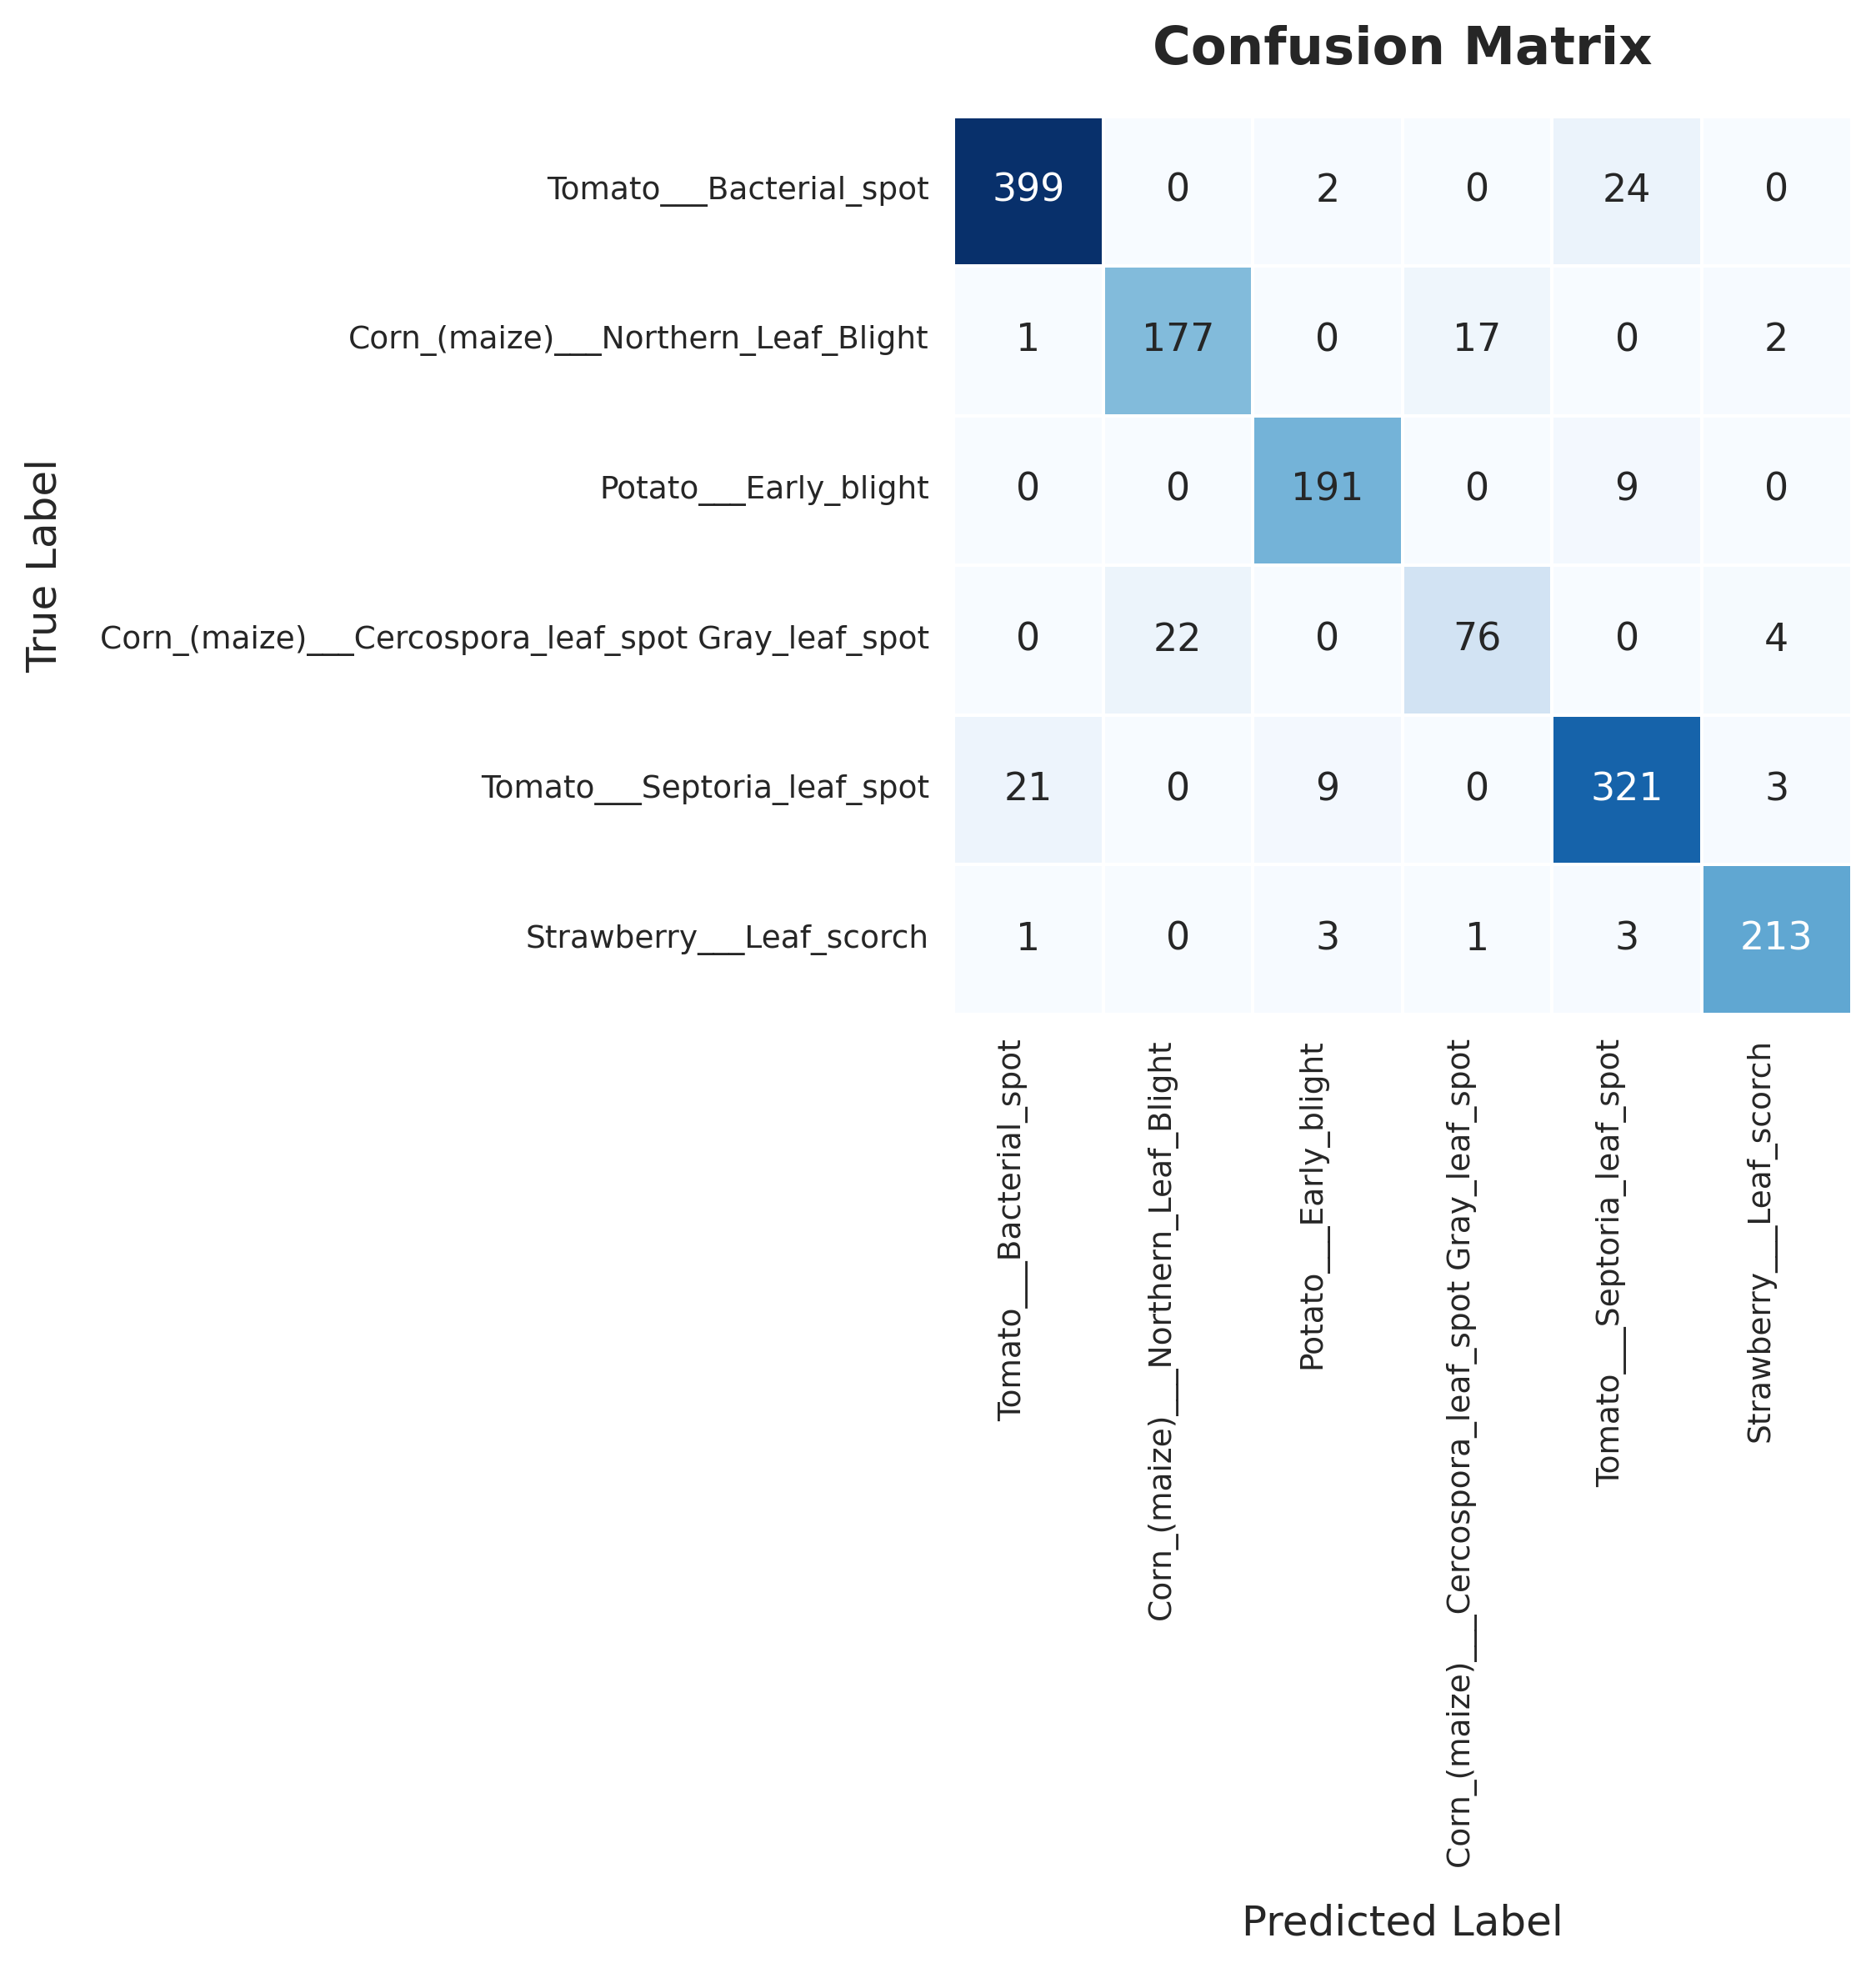

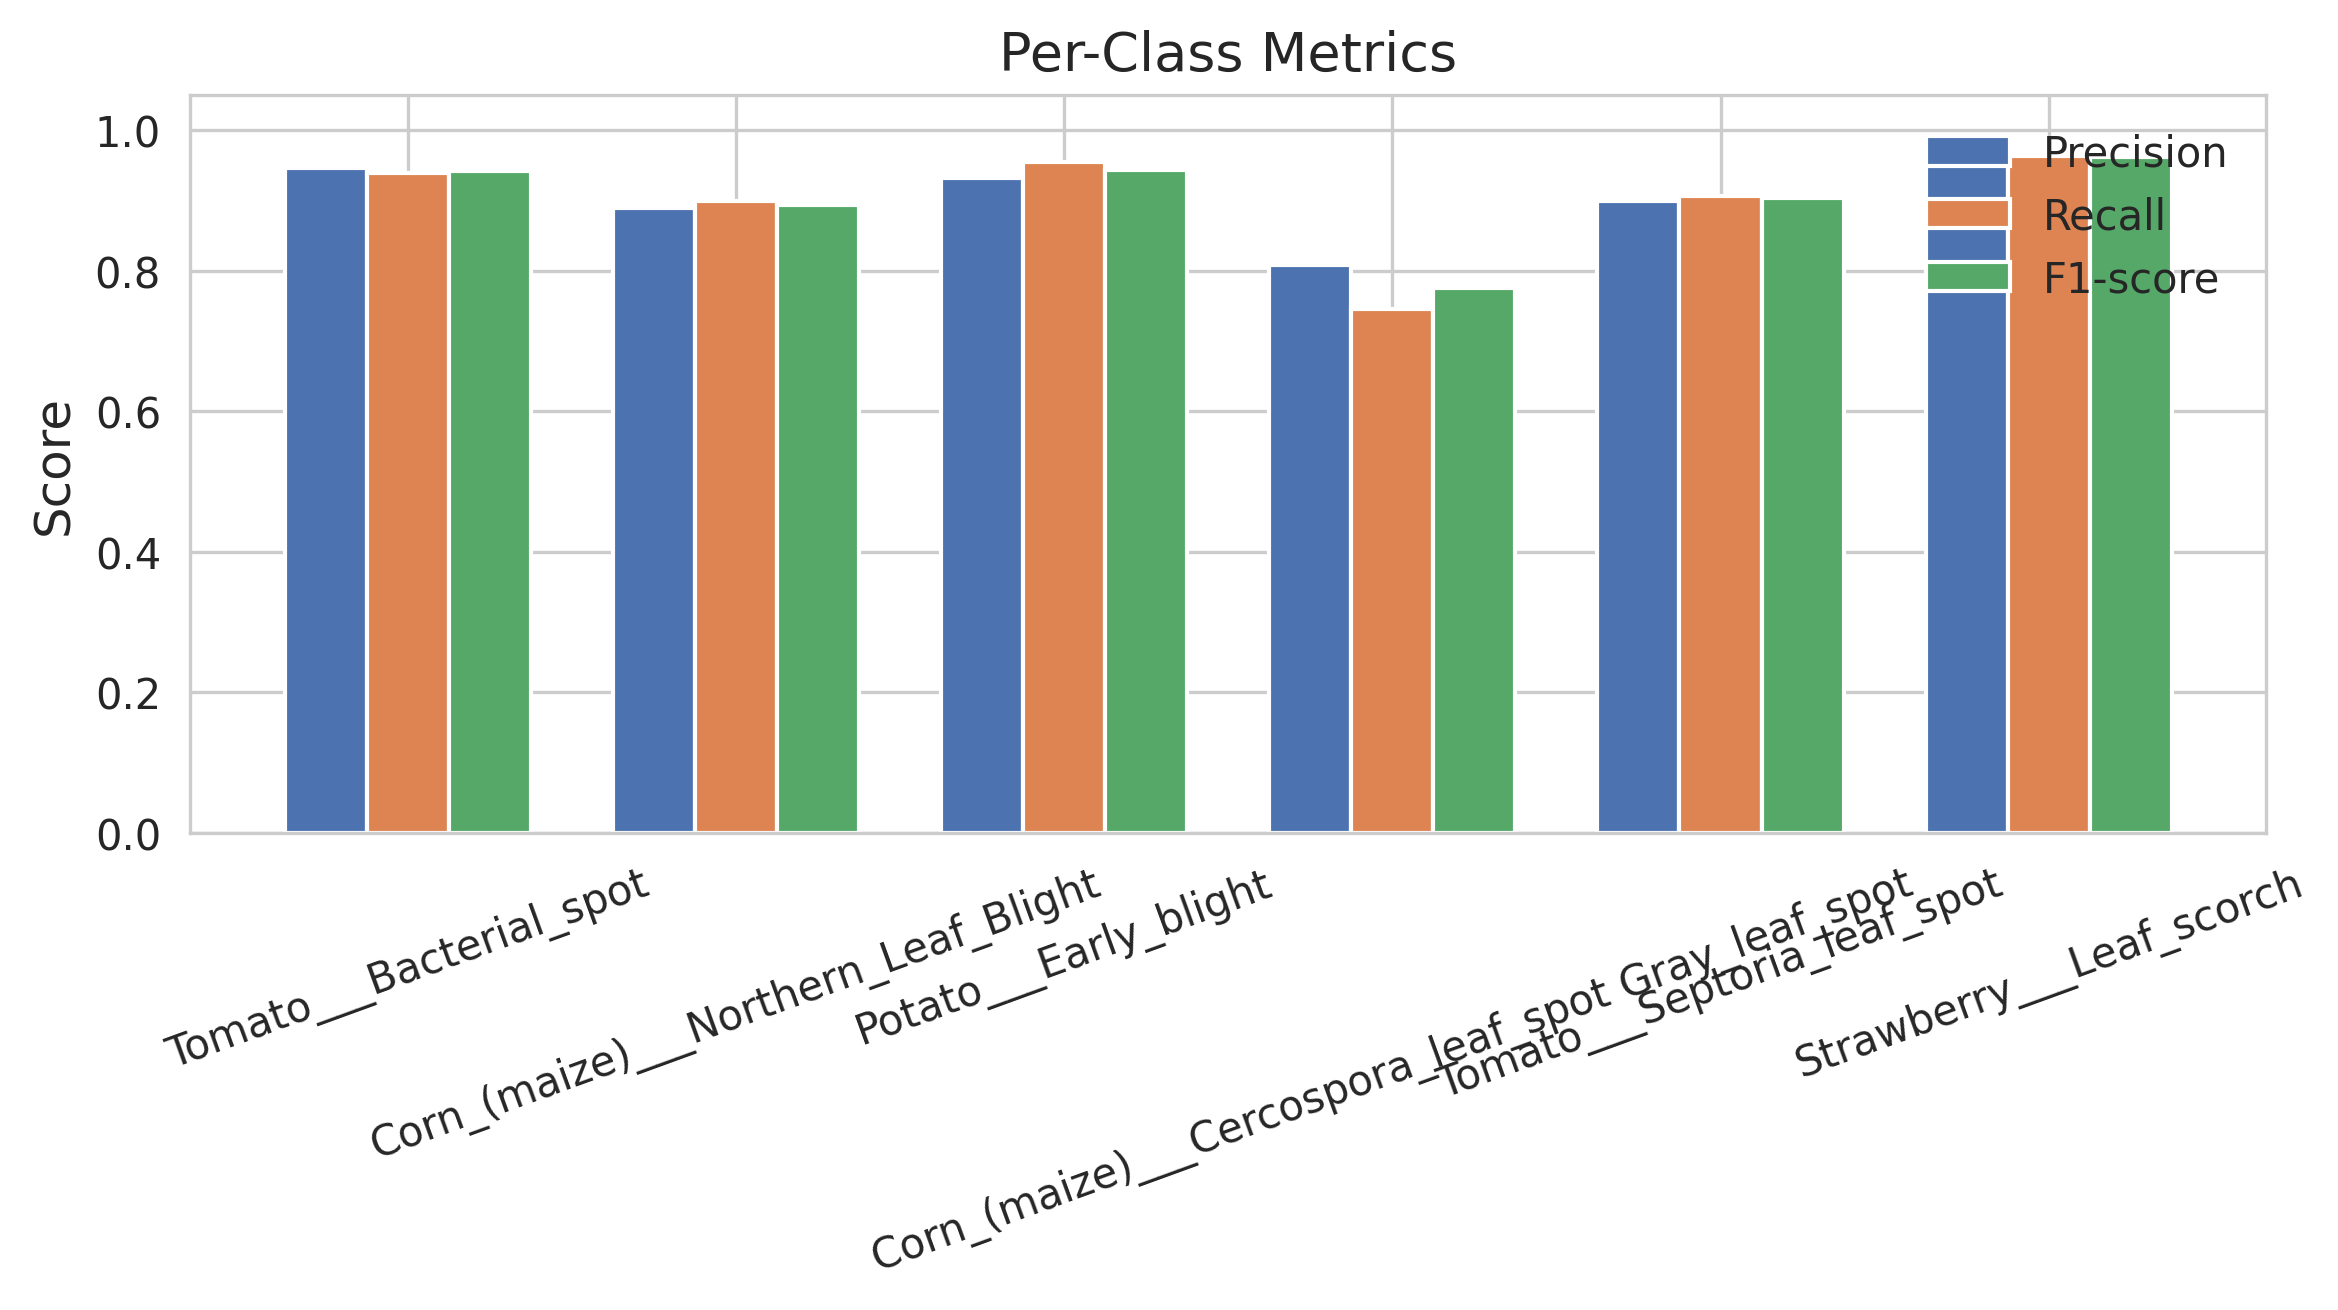

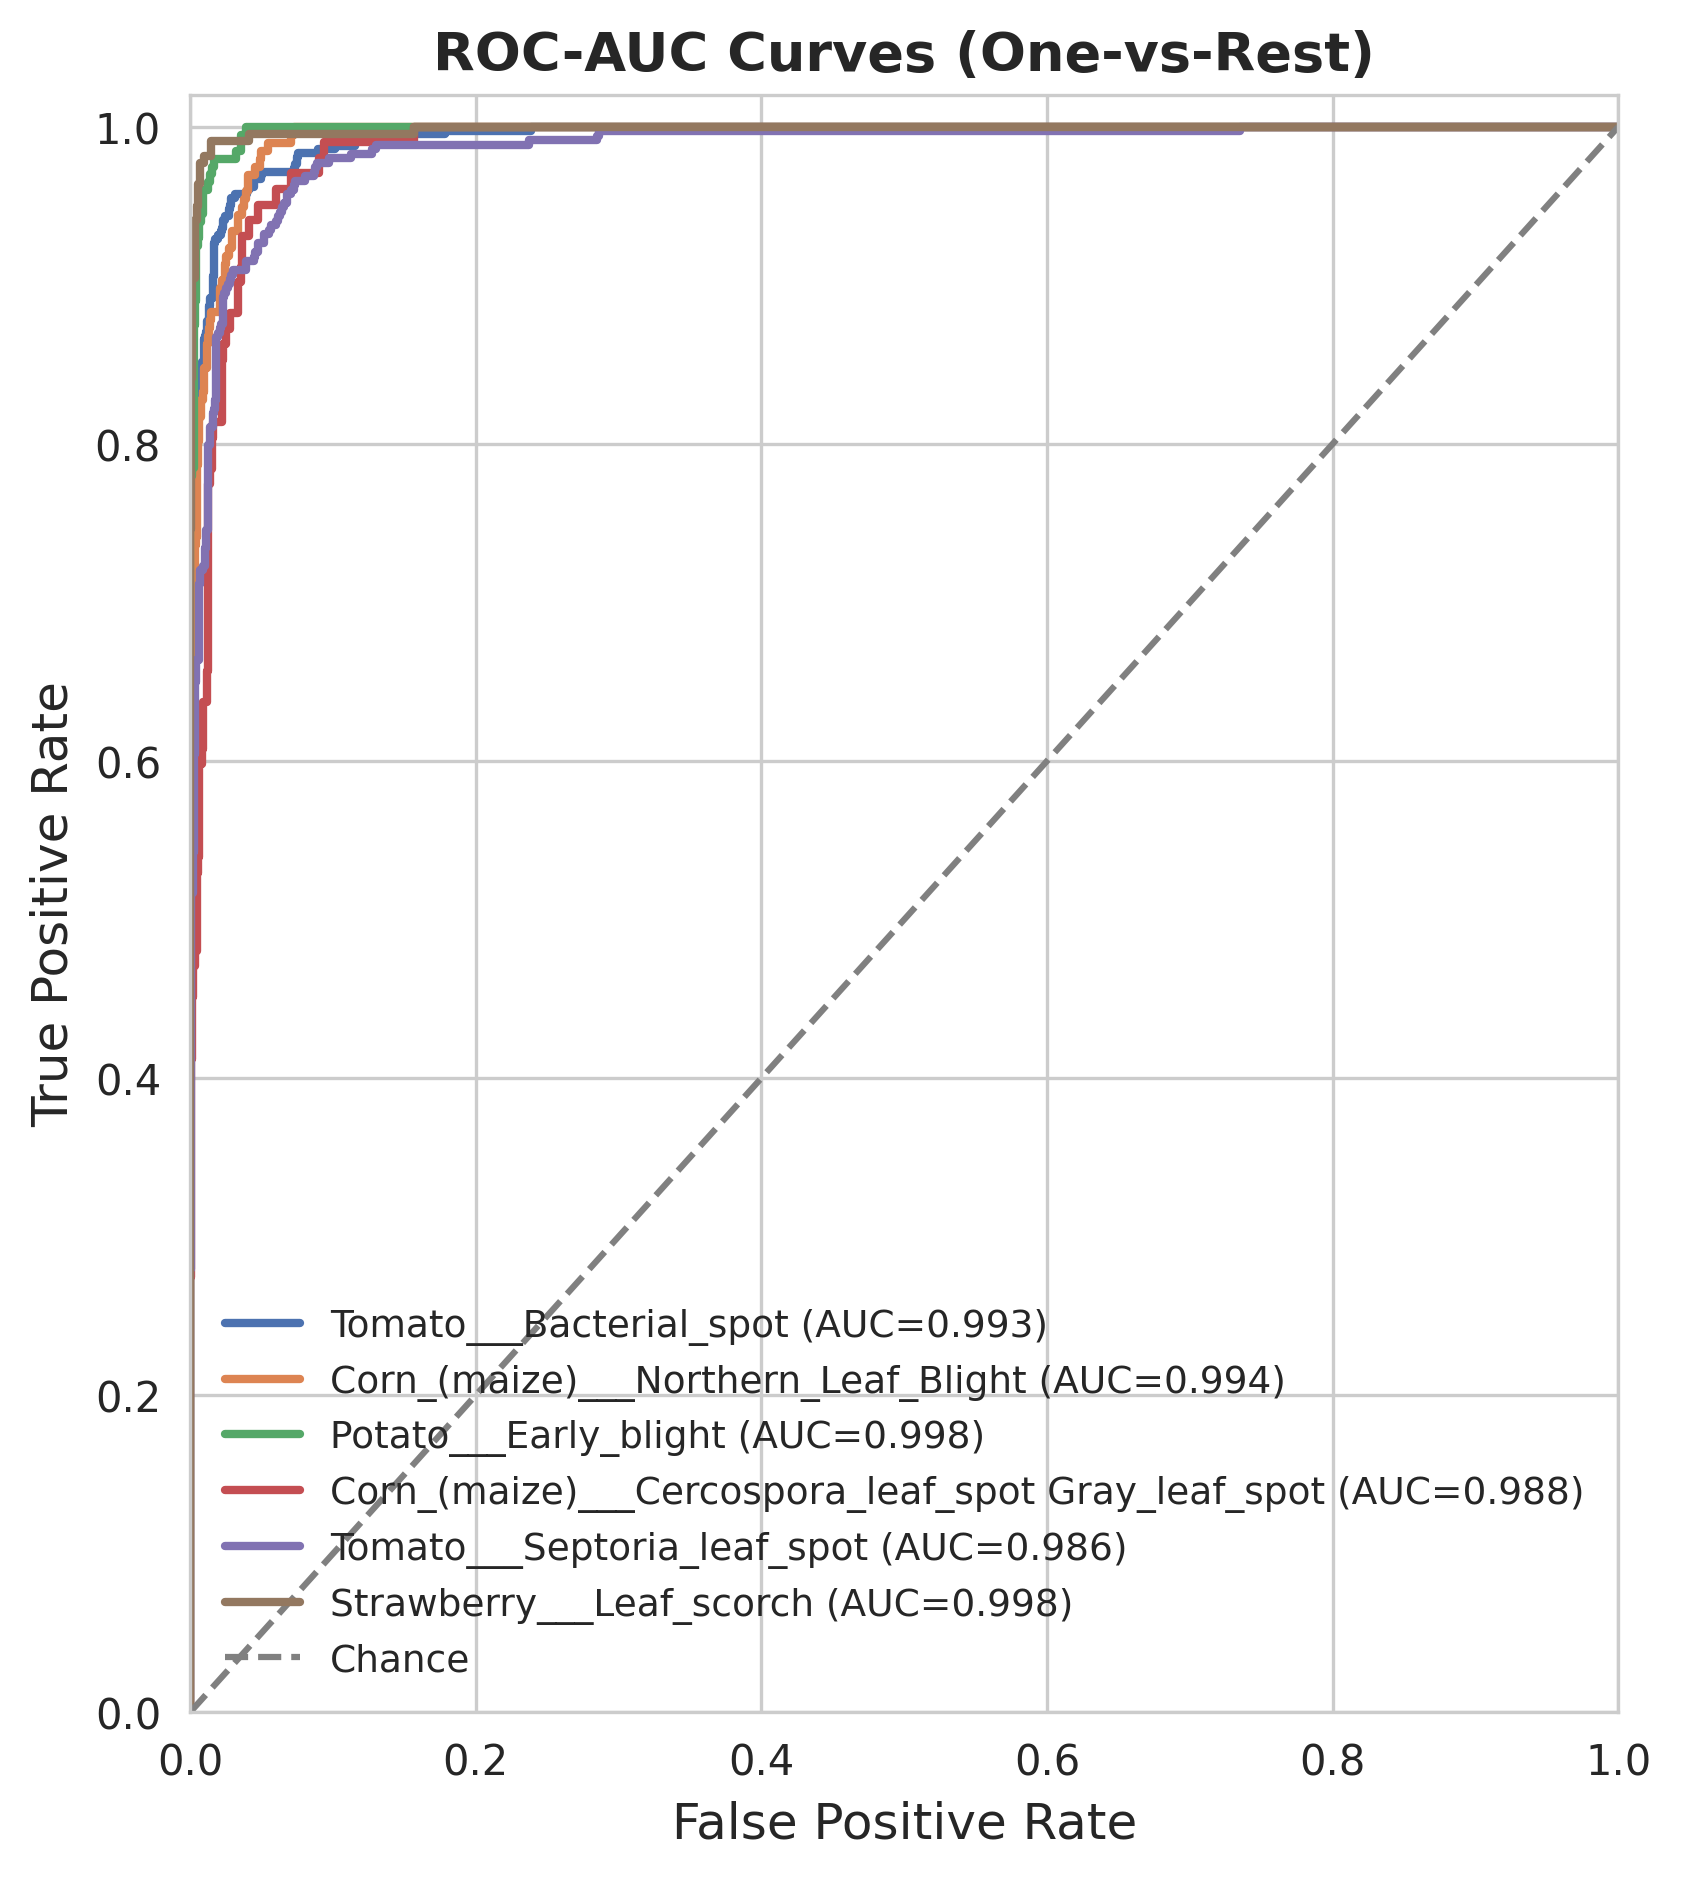

In [166]:
plot_confusion_matrix(y_true, y_pred)
plot_per_class_metrics(y_true, y_pred)
plot_roc_curves(y_true, y_pred_probs)

In [159]:
import matplotlib.pyplot as plt
import numpy as np

def plot_5fold_training_curves(all_histories, save_name="5fold_training_curves.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    max_epochs = max(len(h['val_accuracy']) for h in all_histories)

    # Individual fold curves (light, semi-transparent)
    for i, h in enumerate(all_histories):
        axes[0].plot(h['val_accuracy'], alpha=0.35, color='#4C72B0', linewidth=1)
        axes[1].plot(h['val_loss'], alpha=0.35, color='#4C72B0', linewidth=1)

    # Mean curve across folds (padded/truncated to equal length if needed)
    val_acc_matrix = np.array([h['val_accuracy'][:max_epochs] for h in all_histories
                                 if len(h['val_accuracy']) == max_epochs])
    val_loss_matrix = np.array([h['val_loss'][:max_epochs] for h in all_histories
                                  if len(h['val_loss']) == max_epochs])

    mean_val_acc = val_acc_matrix.mean(axis=0)
    mean_val_loss = val_loss_matrix.mean(axis=0)

    axes[0].plot(mean_val_acc, color='#DD8452', linewidth=2.5, label='Mean (5-fold)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Accuracy')
    axes[0].set_title('Validation Accuracy Across 5 Folds')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.3)

    axes[1].plot(mean_val_loss, color='#DD8452', linewidth=2.5, label='Mean (5-fold)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Loss')
    axes[1].set_title('Validation Loss Across 5 Folds')
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name}", bbox_inches='tight')
    plt.show()



In [34]:
import matplotlib.pyplot as plt

def plot_training_curves_classic(history, save_name_prefix="training_curve"):
    # ===============================================================
    # Accuracy plot
    # ===============================================================
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name_prefix}_accuracy.png", bbox_inches='tight', dpi=150)
    plt.show()

    # ===============================================================
    # Loss plot
    # ===============================================================
    plt.figure(figsize=(7, 5))
    plt.plot(history.history['loss'], marker='o', label='Training Loss')
    plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{save_name_prefix}_loss.png", bbox_inches='tight', dpi=150)
    plt.show()

# Usage:
plot_training_curves_classic(history)

NameError: name 'history' is not defined

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []
all_y_pred_probs = []
all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all_int)):
    print(f"\n{'='*50}\nFold {fold_idx+1}/5\n{'='*50}")

    X_tr, X_va = X_all[train_idx], X_all[val_idx]
    y_tr = tf.keras.utils.to_categorical(y_all_int[train_idx], NUM_CLASSES)
    y_va = tf.keras.utils.to_categorical(y_all_int[val_idx], NUM_CLASSES)
    y_va_int = y_all_int[val_idx]

    x = encoder.output
    x = layers.Dense(NUM_CLASSES, activation='softmax', name='clf_head')(x)
    clf = models.Model(inputs=encoder.input, outputs=x)
    clf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = clf.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                       epochs=EPOCHS_PER_FOLD, batch_size=BATCH_SIZE, verbose=0)
    all_histories.append(history.history)

    probs = clf.predict(X_va, verbose=0)
    preds = np.argmax(probs, axis=1)

    all_y_true.extend(y_va_int)
    all_y_pred.extend(preds)
    all_y_pred_probs.append(probs)

    fold_acc = (preds == y_va_int).mean()
    print(f"Fold {fold_idx+1} done — {len(val_idx)} samples, accuracy: {fold_acc*100:.2f}%")

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_pred_probs = np.concatenate(all_y_pred_probs, axis=0)

print(f"\nCombined out-of-fold accuracy: {(all_y_true == all_y_pred).mean()*100:.2f}%")

# ===============================================================
# Combined confusion matrix
# ===============================================================
plot_confusion_matrix(all_y_true, all_y_pred, save_name="confusion_matrix_5fold_combined.png",
                       title="Confusion Matrix (5-Fold Combined)")

# ===============================================================
# Combined ROC curves
# ===============================================================
plot_roc_curves(all_y_true, all_y_pred_probs, save_name="roc_curves_5fold_combined.png")

# ===============================================================
# Validation accuracy/loss curves across folds
# ===============================================================
plot_5fold_training_curves(all_histories)


Fold 1/5
Fold 1 done — 111 samples, accuracy: 79.28%

Fold 2/5
Fold 2 done — 111 samples, accuracy: 83.78%

Fold 3/5
Fold 3 done — 110 samples, accuracy: 81.82%

Fold 4/5
Fold 4 done — 110 samples, accuracy: 80.00%

Fold 5/5


In [145]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 10.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [153]:
import os
import numpy as np
from PIL import Image

TARGET_DIR = '/media/iot-lab/Projects/Nazifa/Unlearning/feature_unlearning/RiceDiseases-DataSet'

def load_target_images_from_nested(target_dir, img_size=160):   # match your IMG_SIZE
    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    class_names = sorted([
        d for d in os.listdir(target_dir)
        if os.path.isdir(os.path.join(target_dir, d)) and not d.startswith('.')
    ])
    images, labels = [], []
    for label_idx, class_name in enumerate(class_names):
        class_path = os.path.join(target_dir, class_name)
        for subfolder in os.listdir(class_path):
            subfolder_path = os.path.join(class_path, subfolder)
            if not os.path.isdir(subfolder_path):
                continue
            for fname in os.listdir(subfolder_path):
                ext = os.path.splitext(fname)[1].lower()
                if ext not in VALID_EXTENSIONS:
                    continue
                fpath = os.path.join(subfolder_path, fname)
                try:
                    img = Image.open(fpath).convert('RGB')
                    img = img.resize((img_size, img_size))
                    images.append(np.array(img))
                    labels.append(label_idx)
                except Exception as e:
                    print(f"Skipping {fpath}: {e}")
    return np.array(images), np.array(labels), class_names

target_images, target_labels, TARGET_CLASSES = load_target_images_from_nested(TARGET_DIR, img_size=160)

X_all = target_images.astype(np.float32) / 255.0
y_all_int = target_labels

print(f"Loaded {len(X_all)} total images across {len(TARGET_CLASSES)} classes")
print(f"Class distribution: {[(TARGET_CLASSES[i], (y_all_int==i).sum()) for i in range(len(TARGET_CLASSES))]}")

Loaded 552 total images across 3 classes
Class distribution: [('Bacterial leaf blight', np.int64(192)), ('blast', np.int64(160)), ('brownspot', np.int64(200))]



Fold 1/5
Fold 1 — Acc: 83.78%, Precision: 0.843, Recall: 0.838, F1: 0.840

Fold 2/5
Fold 2 — Acc: 85.59%, Precision: 0.861, Recall: 0.856, F1: 0.857

Fold 3/5
Fold 3 — Acc: 82.73%, Precision: 0.830, Recall: 0.827, F1: 0.826

Fold 4/5
Fold 4 — Acc: 80.00%, Precision: 0.807, Recall: 0.800, F1: 0.800

Fold 5/5
Fold 5 — Acc: 79.09%, Precision: 0.791, Recall: 0.791, F1: 0.791

5-Fold CV Summary
Accuracy : 82.24% ± 2.40%
Precision: 0.826 ± 0.025
Recall   : 0.822 ± 0.024
F1-score : 0.823 ± 0.025


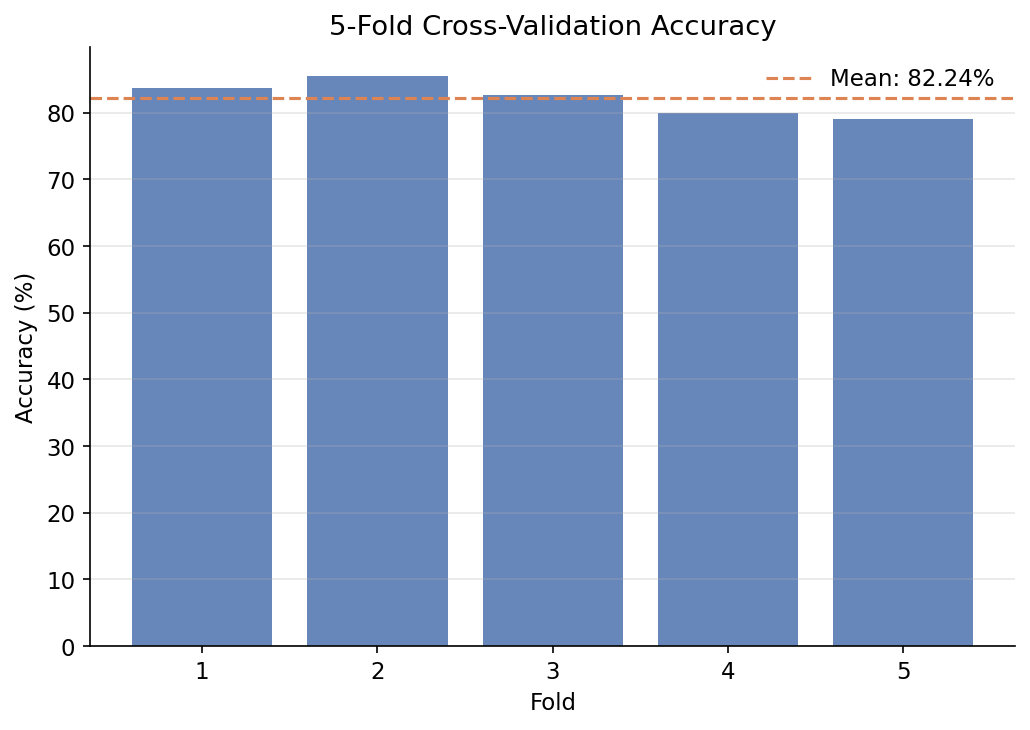

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

# ===============================================================
# Load your trained, frozen encoder (feature extraction only —
# no need to retrain the encoder per fold, only the classifier head)
# ===============================================================
encoder = tf.keras.models.load_model('MV2_Encoder_alpha75_160image_Jul11.h5', compile=False)
encoder.trainable = False

# X_all, y_all_int = your full labeled target dataset (images + integer labels),
# NOT pre-split into train/val — 5-fold CV needs the whole pool
# (recombine your earlier X_train+X_val, y_train+y_val if needed:)
# X_all = np.concatenate([X_train, X_val], axis=0)
# y_all_int = np.concatenate([np.argmax(y_train,1), np.argmax(y_val,1)], axis=0)

NUM_CLASSES = 6
EPOCHS_PER_FOLD = 40
BATCH_SIZE = 32

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all_int)):
    print(f"\n{'='*50}\nFold {fold_idx+1}/5\n{'='*50}")

    X_tr, X_va = X_all[train_idx], X_all[val_idx]
    y_tr = tf.keras.utils.to_categorical(y_all_int[train_idx], NUM_CLASSES)
    y_va = tf.keras.utils.to_categorical(y_all_int[val_idx], NUM_CLASSES)

    # Fresh classifier head each fold, same frozen encoder
    x = encoder.output
    x = layers.Dense(NUM_CLASSES, activation='softmax', name='clf_head')(x)
    clf = models.Model(inputs=encoder.input, outputs=x)
    clf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    clf.fit(X_tr, y_tr, validation_data=(X_va, y_va),
            epochs=EPOCHS_PER_FOLD, batch_size=BATCH_SIZE, verbose=0)

    y_pred = np.argmax(clf.predict(X_va, verbose=0), axis=1)
    y_true = np.argmax(y_va, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_f1s.append(f1)

    print(f"Fold {fold_idx+1} — Acc: {acc*100:.2f}%, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

# ===============================================================
# Summary statistics
# ===============================================================
print(f"\n{'='*50}\n5-Fold CV Summary\n{'='*50}")
print(f"Accuracy : {np.mean(fold_accuracies)*100:.2f}% ± {np.std(fold_accuracies)*100:.2f}%")
print(f"Precision: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}")
print(f"Recall   : {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}")
print(f"F1-score : {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")

# ===============================================================
# Plot: per-fold accuracy with mean line
# ===============================================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(range(1, 6), [a*100 for a in fold_accuracies], color='#4C72B0', alpha=0.85)
ax.axhline(np.mean(fold_accuracies)*100, color='#DD8452', linestyle='--',
           label=f'Mean: {np.mean(fold_accuracies)*100:.2f}%')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.set_xticks(range(1, 6))
ax.legend(frameon=False)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('paper_figures/5fold_cv_accuracy.png', bbox_inches='tight')
plt.show()